# EDA

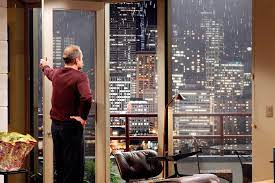

In [53]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

In [54]:
# Load the dataset
df = pd.read_csv("data/eda.csv")

In [55]:
df.shape

(21597, 23)

In [56]:
# Check the dimensions of the dataset
df.shape

(21597, 23)

In [57]:
# Display the first 5 rows
df.head()

,sale_id,date,price,house_id,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,1,2014-10-13,221900.000,7129300520,7129300520,3.000,1.000,1180.000,5650.000,1.000,...,7,1180.000,0.000,1955,0.000,98178,47.511,-122.257,1340.000,5650.000
1,2,2014-12-09,538000.000,6414100192,6414100192,3.000,2.250,2570.000,7242.000,2.000,...,7,2170.000,400.000,1951,19910.000,98125,47.721,-122.319,1690.000,7639.000
2,3,2015-02-25,180000.000,5631500400,5631500400,2.000,1.000,770.000,10000.000,1.000,...,6,770.000,0.000,1933,NaN,98028,47.738,-122.233,2720.000,8062.000
3,4,2014-12-09,604000.000,2487200875,2487200875,4.000,3.000,1960.000,5000.000,1.000,...,7,1050.000,910.000,1965,0.000,98136,47.521,-122.393,1360.000,5000.000
4,5,2015-02-18,510000.000,1954400510,1954400510,3.000,2.000,1680.000,8080.000,1.000,...,8,1680.000,0.000,1987,0.000,98074,47.617,-122.045,1800.000,7503.000


In [58]:
# Check columns, data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sale_id        21597 non-null  int64  
 1   date           21597 non-null  str    
 2   price          21597 non-null  float64
 3   house_id       21597 non-null  int64  
 4   id             21597 non-null  int64  
 5   bedrooms       21597 non-null  float64
 6   bathrooms      21597 non-null  float64
 7   sqft_living    21597 non-null  float64
 8   sqft_lot       21597 non-null  float64
 9   floors         21597 non-null  float64
 10  waterfront     19206 non-null  float64
 11  view           21534 non-null  float64
 12  condition      21597 non-null  int64  
 13  grade          21597 non-null  int64  
 14  sqft_above     21597 non-null  float64
 15  sqft_basement  21145 non-null  float64
 16  yr_built       21597 non-null  int64  
 17  yr_renovated   17749 non-null  float64
 18  zipcode        21

In [59]:
# die fehlenden Werte zählen
# Check missing values per column
df.isna().sum()

sale_id             0
date                0
price               0
house_id            0
id                  0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront       2391
view               63
condition           0
grade               0
sqft_above          0
sqft_basement     452
yr_built            0
yr_renovated     3848
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
dtype: int64

In [60]:
# Werte anschauen
# Check unique values in columns with missing data

print("waterfront:")
print(df["waterfront"].value_counts(dropna=False)) # Panda zeigt auch die NaN-Werte an.

print("\nview:")
print(df["view"].value_counts(dropna=False))

print("\nyr_renovated:")
print(df["yr_renovated"].value_counts(dropna=False).head(15))

waterfront:
waterfront
0.000    19060
NaN       2391
1.000      146
Name: count, dtype: int64

view:
view
0.000    19422
2.000      957
3.000      508
1.000      330
4.000      317
NaN         63
Name: count, dtype: int64

yr_renovated:
yr_renovated
0.000        17005
NaN           3848
20140.000       73
20130.000       31
20030.000       31
20070.000       30
20050.000       29
20000.000       29
19900.000       22
20040.000       22
20090.000       21
19890.000       20
20060.000       20
20020.000       17
19910.000       16
Name: count, dtype: int64


In [61]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

In [62]:
# Statistical summary of numerical columns
# Das .T dreht die Tabelle, sodass jede Variable eine Zeile ist.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sale_id,21597.000,10799.000,6234.661,1.000,5400.000,10799.000,16198.000,21597.000
price,21597.000,540296.574,367368.140,78000.000,322000.000,450000.000,645000.000,7700000.000
house_id,21597.000,4580474287.771,2876735715.748,1000102.000,2123049175.000,3904930410.000,7308900490.000,9900000190.000
id,21597.000,4580474287.771,2876735715.748,1000102.000,2123049175.000,3904930410.000,7308900490.000,9900000190.000
bedrooms,21597.000,3.373,0.926,1.000,3.000,3.000,4.000,33.000
bathrooms,21597.000,2.116,0.769,0.500,1.750,2.250,2.500,8.000
sqft_living,21597.000,2080.322,918.106,370.000,1430.000,1910.000,2550.000,13540.000
sqft_lot,21597.000,15099.409,41412.637,520.000,5040.000,7618.000,10685.000,1651359.000
floors,21597.000,1.494,0.540,1.000,1.000,1.500,2.000,3.500
waterfront,19206.000,0.008,0.087,0.000,0.000,0.000,0.000,1.000


In [63]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Check the result
df["date"].dtype

dtype('<M8[us]')

In [64]:
# Es wird zwei neue Spalten für die Timing-Hypothese erstellt:
# Create year and month columns
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

# Check the result
df[["date", "year", "month"]].head()

,date,year,month
0,2014-10-13,2014,10
1,2014-12-09,2014,12
2,2015-02-25,2015,2
3,2014-12-09,2014,12
4,2015-02-18,2015,2


In [65]:
# Damit sehen wir, wie häufig 1, 2, 3, 4 … bis 33 Schlafzimmer vorkommen.
# Check extreme values for bedrooms
df["bedrooms"].value_counts().sort_index()

bedrooms
1.000      196
2.000     2760
3.000     9824
4.000     6882
5.000     1601
6.000      272
7.000       38
8.000       13
9.000        6
10.000       3
11.000       1
33.000       1
Name: count, dtype: int64

Die Verteilung zeigt, dass die meisten Häuser zwischen 2 und 5 Schlafzimmern haben. Danach werden die Fälle sehr selten:

10 Schlafzimmer → 3 Häuser
11 Schlafzimmer → 1 Haus
33 Schlafzimmer → nur 1 Haus

In [66]:
# Inspect the house with 33 bedrooms
df[df["bedrooms"] == 33]


,sale_id,date,price,house_id,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month
15856,15857,2014-06-25,640000.000,2402100895,2402100895,33.000,1.750,1620.000,6000.000,1.000,...,580.000,1947,0.000,98103,47.688,-122.331,1330.000,4700.000,2014,6


Als nächsten Schritt definiere ich zunächst das middle price range, weil das für Nicole zentral ist. Eine nachvollziehbare Definition sind die mittleren 50 % des Marktes:

In [67]:
# Define the middle price range using the 25th and 75th percentiles
lower_price = df["price"].quantile(0.25)
upper_price = df["price"].quantile(0.75)

print("Lower limit:", lower_price)
print("Upper limit:", upper_price)

Lower limit: 322000.0
Upper limit: 645000.0


Assumption: For this analysis, the middle price range is defined as the middle 50% of house prices (25th–75th percentile).


In [68]:
# True bedeutet: Haus liegt zwischen $322k und $645k.
# False bedeutet: Haus liegt außerhalb dieses Bereichs.
#  Create a boolean column for houses in the middle price range
df["middle_price"] = df["price"].between(lower_price, upper_price)

# Count houses inside and outside the middle price range
df["middle_price"].value_counts()

middle_price
True     10832
False    10765
Name: count, dtype: int64

### H1 – Location

Unsere Hypothese ist:

Houses located closer to central Seattle are more expensive than houses farther away from the city center.

Für Nicole interessiert uns zusätzlich: Gibt es trotzdem zentrale Gegenden mit Häusern im mittleren Preisbereich ($322k–$645k)?

Wir haben lat und long. Damit können wir später die Entfernung zum Zentrum von Seattle berechnen. Bevor wir das tun, prüfen wir zunächst, ob die Koordinaten vernünftig aussehen.


In [69]:
# Check the geographical range of the dataset
df[["lat", "long"]].describe()

,lat,long
count,21597.000,21597.000
mean,47.560,-122.214
std,0.139,0.141
min,47.156,-122.519
25%,47.471,-122.328
50%,47.572,-122.231
75%,47.678,-122.125
max,47.778,-121.315


### Assumption – Central Seattle

For this analysis, Central Seattle is represented by the coordinates
**47.6062° N, 122.3321° W**.

The latitude and longitude values in the dataset will be used to calculate
the approximate distance of each house from Central Seattle.

In [70]:
# Coordinates of Central Seattle
seattle_lat = 47.6062
seattle_long = -122.3321

In [71]:
# Schritt 2: Entfernung berechnen
# “I calculated the approximate distance of each property from Central Seattle based on its latitude and longitude.”

import numpy as np

# Haversine function to calculate distance between two coordinates
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Radius of the Earth in kilometers

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2)**2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [ ]:
# Schritt 3: Neue Spalte erzeugen
# Berechnung der Entfernung von jedem Haus zu Stadtmitte Seattle
# Calculate distance of each house from Central Seattle
df["distance_to_center_km"] = haversine(
    df["lat"],
    df["long"],
    seattle_lat,
    seattle_long
)

In [73]:
df["distance_to_center_km"].describe()

count   21597.000
mean       18.451
std        10.637
min         0.983
25%         9.783
50%        16.504
75%        25.261
max        77.094
Name: distance_to_center_km, dtype: float64

In [74]:
# Correlation between distance to Central Seattle and house price
df[["distance_to_center_km", "price"]].corr()

,distance_to_center_km,price
distance_to_center_km,1.000,-0.287
price,-0.287,1.000


### First finding – Location

There is a negative correlation (r = -0.287) between the distance
to Central Seattle and house prices.

This suggests that houses located farther away from Central Seattle
tend to be less expensive. However, the relationship is relatively weak,
indicating that other factors also influence house prices.


wir teilen alle Häuser Gruppen ein, wie weit sie vom Zentrum Seattles entfernt sind. 
Dann gruppieren wir anschließend die Häuser nach diesen Entfernungsbereichen und
berechne für jede Gruppe die Anzahl der Verkäufe,
den Medianpreis und den Durchschnittspreis.
1. Entfernungsgruppe bilden 
< distance_bins = [0, 5, 10, 15, 20, 30, 100]> 

2. den Gruppen Namen geben. Deshalb brauchen wir genau 6 Labels. 
< distance_labels = [ "0–5 km", "5–10 km", "10–15 km", "15–20 km", "20–30 km", "30+ km"]>

3. wir teilen die Zahlen in Gruppen mit der Funktion 
< df["distance_group"] = pd.cut(
    df["distance_to_center_km"],
    bins=distance_bins,
    labels=distance_labels
)>
4. Gruppieren die Häuser nach Entfernung und untersuche anschließend die Preise jeder Gruppe.“ 
< df.groupby("distance_group", observed=True)["price"]>

5. Berechnen für jede Entfernungsgruppe mehrere Kennzahlen. 
< .agg(["count", "median", "mean"])>

In [75]:
# Create distance groups from Central Seattle
distance_bins = [0, 5, 10, 15, 20, 30, 100]
distance_labels = [
    "0–5 km",
    "5–10 km",
    "10–15 km",
    "15–20 km",
    "20–30 km",
    "30+ km"
]

df["distance_group"] = pd.cut(
    df["distance_to_center_km"],
    bins=distance_bins,
    labels=distance_labels
)

# Compare house prices by distance group
price_by_distance = (
    df.groupby("distance_group", observed=True)["price"]
      .agg(["count", "median", "mean"])
)

price_by_distance

,count,median,mean
distance_group,,,
0–5 km,1343,638000.000,772116.984
5–10 km,4275,537000.000,652830.925
10–15 km,3799,466750.000,579138.356
15–20 km,3962,449000.000,520114.896
20–30 km,4455,458000.000,508183.382
30+ km,3763,309780.000,349769.064


In [76]:
df[["price", "distance_to_center_km", "distance_group"]].head(10)

,price,distance_to_center_km,distance_group
0,221900.000,11.973,10–15 km
1,538000.000,12.803,10–15 km
2,180000.000,16.417,15–20 km
3,604000.000,10.538,10–15 km
4,510000.000,21.554,20–30 km
5,1230000.000,25.131,20–30 km
6,257500.000,32.972,30+ km
7,291850.000,21.910,20–30 km
8,229500.000,10.448,10–15 km
9,323000.000,34.800,30+ km


### H1 – Location: Summary

To investigate the relationship between location and house prices, we defined Central Seattle as a reference point and calculated the distance of each house from the city center using latitude and longitude.

First, i examined the correlation between distance and price. The correlation was **-0.287**, indicating that house prices tend to decrease as the distance from Central Seattle increases, although the relationship is relatively weak.

To make the relationship easier to interpret, i divided the properties into distance groups and calculated the median and mean house prices for each group.

The median house price generally decreases with increasing distance from Central Seattle:

- **0–5 km:** $638,000
- **5–10 km:** $537,000
- **10–15 km:** $466,750
- **15–20 km:** $449,000
- **20–30 km:** $458,000
- **30+ km:** $309,780

Overall, the results support our hypothesis that houses closer to Central Seattle **tend to be more expensive** than houses farther away.

For Nicole, the **5–10 km and 10–15 km areas appear particularly interesting**, because their median prices fall within the defined middle price range of **$322,000–$645,000**.

In [ ]:
import matplotlib.pyplot as plt

# Bar chart: median house price by distance group
ax = price_by_distance["median"].plot(kind="bar")

plt.title("Median House Price by Distance from Central Seattle")
plt.xlabel("Distance from Central Seattle")
plt.ylabel("Median House Price ($)")
plt.xticks(rotation=45)

# Add price labels on top of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"${value/1000:.0f}k" for value in price_by_distance["median"]],
        padding=3
    )

plt.tight_layout()
plt.show()

## H2 – Timing

**Hypothesis:** House prices vary depending on the time of year, meaning that some months offer better buying opportunities than others.

**Question:** Are there certain months that offer better buying opportunities for Nicole?

In [79]:
# Check the time range of the dataset
print("First sale:", df["date"].min())
print("Last sale:", df["date"].max())

First sale: 2014-05-02 00:00:00
Last sale: 2015-05-27 00:00:00


1. Was macht der Code? df["date"].dt.month --> nimmt aus jedem Verkaufsdatum nur den Monat heraus.
2. .groupby(...) gruppiert die Häuser nach diesen Monaten.
3. ["price"].count() zählt, wie viele Verkäufe es in jedem Monat gibt.

In [ ]:
# Number of house sales by month
sales_by_month = (
    df.groupby(df["date"].dt.month)["price"] 
      .count()
)

sales_by_month

date
1      978
2     1247
3     1875
4     2229
5     2414
6     2178
7     2211
8     1939
9     1771
10    1876
11    1409
12    1470
Name: price, dtype: int64

In [81]:
# Nächster Schritt: Medianpreis pro Monat. Ergänzen wir median und mean:
# Compare house prices by month
price_by_month = (
    df.groupby(df["date"].dt.month)["price"]
      .agg(["count", "median", "mean"])
)

price_by_month

,count,median,mean
date,,,
1,978,438500.000,525963.252
2,1247,426500.000,508520.051
3,1875,450000.000,544057.683
4,2229,477000.000,562215.615
5,2414,462000.000,550849.747
6,2178,465000.000,557534.318
7,2211,465000.000,544892.161
8,1939,442200.000,536655.212
9,1771,450000.000,529723.518


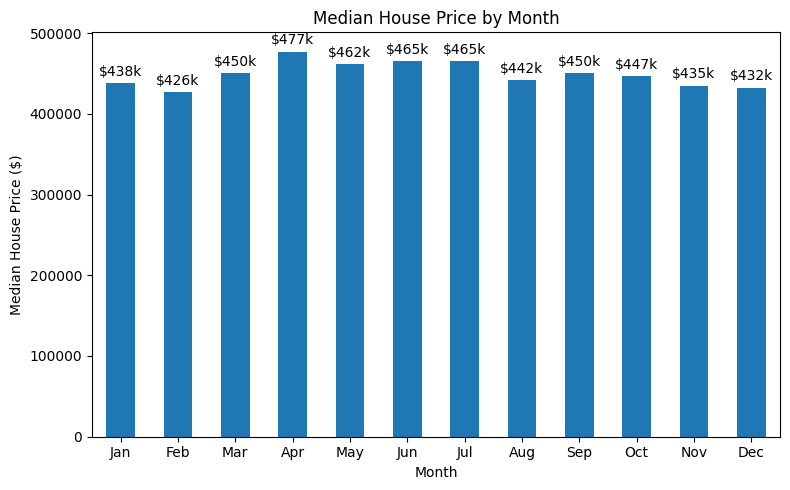

In [82]:
# Median house price by month

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

ax = price_by_month["median"].plot(kind="bar")

plt.title("Median House Price by Month")
plt.xlabel("Month")
plt.ylabel("Median House Price ($)")

ax.set_xticklabels(month_names, rotation=0)

# Add price labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"${value/1000:.0f}k" for value in price_by_month["median"]],
        padding=3
    )

plt.tight_layout()
plt.show()

### Client-specific Timing Analysis

Based on the H1 results, properties within 15 km of Central Seattle are considered relatively central for this analysis.

We now focus on properties that meet both of Nicole's main criteria:

- Located within 15 km of Central Seattle
- Sale price within the middle price range ($322k–$645k)

The goal is to investigate whether certain months offer more attractive buying opportunities within this relevant market segment.

In [83]:
# Filter properties relevant for Nicole:
# middle price range AND within 15 km of Central Seattle

nicole_df = df[
    (df["price"].between(lower_price, upper_price)) &
    (df["distance_to_center_km"] <= 15)
].copy()

# Check number of relevant properties
nicole_df.shape

(4791, 28)

In [84]:
# Nächster Schritt: Timing nur für Nicoles Segment
# Wir wollen jetzt pro Monat wissen:
# Wie viele passende Häuser wurden verkauft?
# Wie hoch war deren Medianpreis?
# Wie hoch war deren Durchschnittspreis?
# Analyze prices by month for Nicole's relevant market segment
nicole_price_by_month = (
    nicole_df.groupby(nicole_df["date"].dt.month)["price"]
             .agg(["count", "median", "mean"])
)

nicole_price_by_month


,count,median,mean
date,,,
1,186,464500.000,470749.753
2,267,467500.000,480340.652
3,393,469000.000,477859.374
4,508,479500.000,479371.280
5,569,464000.000,470722.221
6,466,462500.000,470762.073
7,483,480000.000,479169.493
8,422,460500.000,473739.557
9,414,463000.000,471324.307


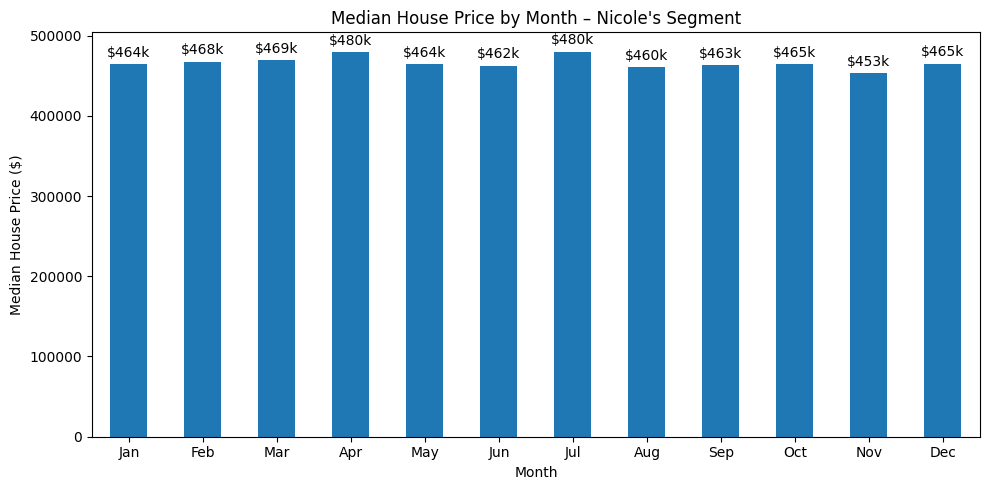

In [85]:
# Median house price by month for Nicole's relevant segment

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

ax = nicole_price_by_month["median"].plot(kind="bar", figsize=(10, 5))

plt.title("Median House Price by Month – Nicole's Segment")
plt.xlabel("Month")
plt.ylabel("Median House Price ($)")
plt.xticks(range(12), month_names, rotation=0)

# Add price labels on top of the bars
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"${value/1000:.0f}k"
            for value in nicole_price_by_month["median"]
        ],
        padding=3
    )

plt.tight_layout()
plt.show()